## User Notebook

### Introduction

This user notebook provides an overview of the core commands of the STL library for statistical scattering analysis. Its purpose is to guide users through the fundamental operations required to compute **scattering statistics** and **cross-statistics between channels**, for both **periodic** and **non-periodic** domains. Other basic statistical quantities such as **mean**, **variance**, and **power spectrum** are also available.

Beyond analysis, the library also supports **data synthesis** based on target statistics. This notebook demonstrates how to define **custom loss functions** that compare statistical descriptors, and how to **run optimization procedures** to generate signals or fields that match desired statistical properties.

Examples are provided to illustrate typical workflows and recommended usage patterns.

In [9]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt

import os
import sys


# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../"))
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("//")[-1])

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset directory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch as DataClass
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../c:\Users\Danie\Bureau\STL-Dev
Dataset directory used: .../c:\Users\Danie\Bureau\STL-Dev/data/test
Working on device: cpu


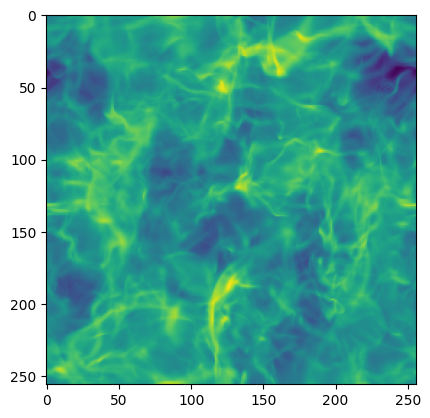

In [ ]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]

# Instantiate STL data class
data = DataClass(array=im[0,0], pbc=True) # shall specify both array and pbc status

# Visualize loaded data
plt.imshow(data.array.cpu().numpy())

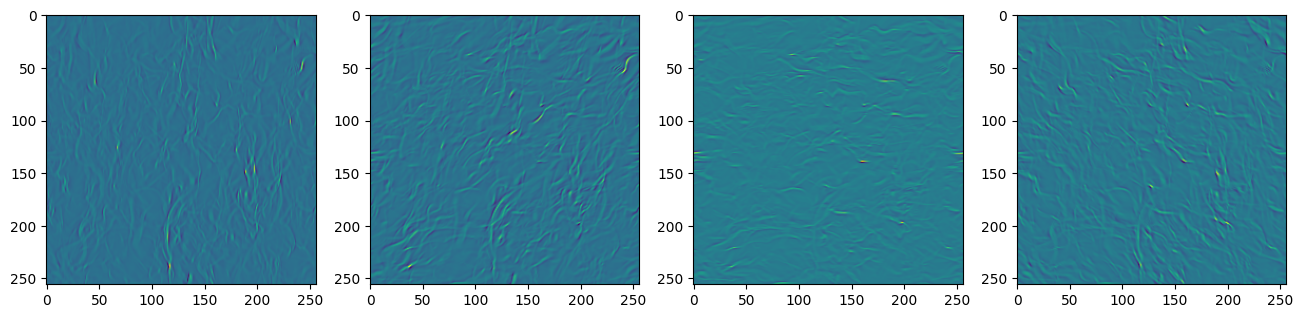

In [ ]:
# get a wavelet operator from the data class
w_op = data.get_wavelet_op() # may specify here, maximum scale J and orientation number L

# apply the wavelet operator to the data at a given scale (here at j=0)
w_data = w_op.apply(data, j=0)

# note: for FFT data class, the wavelet coefficients may also all computed at once 
# using j=None : w_data = w_op.apply(stl_data)


plt.figure(figsize=(16,6))
for k in range(4):
    plt.subplot(1,4,1+k)
    plt.imshow(w_data.array[k].cpu().numpy().real)

In [13]:
# get a ST operator from the data class
st_op = data.get_ST_op() # May specify J, L, many transformation to apply (norm, iso, flatten) as well as power spectrum computation

# apply the ST operator to the data
st_data = st_op.apply(data)

In [ ]:
tmp = im[0,0].copy()
np.random.seed(27)
tmp[(np.random.rand(300)*tmp.shape[0]).astype('int'),
    (np.random.rand(300)*tmp.shape[0]).astype('int')] = np.nan
tmp[50:60,50:60] = np.nan

l_data = DataClass(tmp, pbc=True)